# Reading labels off crates: how i built it and what went wrong

I built a thing that reads the label on a crate of ingredients turning up at a food factory,
works out what is actually in the crate, and decides whether it is allowed onto whatever the
factory is making today.

This notebook is the story of building it, roughly in the order it happened, with the code that
matters and the bits I got wrong. Everything below is produced by running it, nothing is pasted
in.

The thing I did not understand at the start, and which turned out to be the whole project:

> reading text off a picture is one line of python. deciding **which readings you can trust** is
> the actual job. a reader that is right 96% of the time is no use if somebody still has to check
> all sixty rows to find the four it got wrong.

In [1]:
import csv, glob, inspect, os, sys
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

sys.path.insert(0, os.getcwd())

import ocr_reader as reader
import pytesseract
from preprocess import clean, deskew, deperspective
from validate import check_crate, load_rules, outcome
from textutil import edit_distance

plt.rcParams["figure.dpi"] = 110


def show(img, title="", w=8):
    plt.figure(figsize=(w, w * img.shape[0] / img.shape[1]))
    plt.imshow(img, cmap="gray")
    plt.title(title, fontsize=10, loc="left")
    plt.axis("off")
    plt.show()


def show_code(fn):
    # so the actual code is in the notebook rather than me describing it
    display(Markdown("```python\n" + inspect.getsource(fn) + "```"))


print("opencv", cv2.__version__, "| tesseract", pytesseract.get_tesseract_version())

opencv 5.0.0 | tesseract 5.4.0.20240606


## first problem: i had nothing to read

I wanted to measure accuracy, and you cannot measure accuracy without knowing the right answer.
There is no public dataset of goods-in labels with the batch numbers written down next to them,
because that is commercially sensitive and nobody publishes theirs.

So I generate the labels and keep the answers. But I did not want the whole thing to be made up,
so the **catalogue they get checked against is real** — 400-odd products off Open Food Facts, with
their real barcodes, real brands and, the bit that ended up mattering most, **real allergens**.

In [2]:
rules = load_rules()
products = rules["products"]
print(len(products), "real products\n")
for c, rec in list(products.items())[:5]:
    print("%-15s %-32s %-14s %s" % (c, rec["product_name"][:32], rec["brand"][:14],
                                    "|".join(sorted(rec["allergens"])) or "-"))

407 real products

0039047001442   Shortbread Highlanders           Walkers        gluten|milk|nuts
0039047011496   Pure butter shortbread           Walkers        gluten|milk|nuts|soybeans
0061232200293   Oatcakes - Organic               Nairn's        gluten|milk|nuts
0061232200545   Fine Milled Oatcakes             nairn's        gluten
0061232201047   Stem Ginger Oat Biscuits         Nairn's        gluten


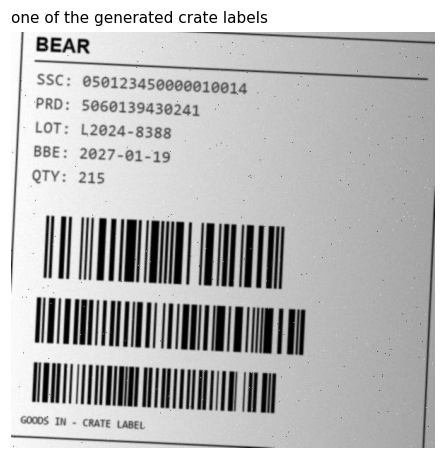

In [3]:
label = cv2.imread(sorted(glob.glob("data/labels/*.png"))[1], cv2.IMREAD_GRAYSCALE)
show(label, "one of the generated crate labels", w=5)

Rotated a bit, shadow across it, blurred, speckled, saved as a bad JPEG. The text prints grey
rather than black because thermal printers fade, and that one setting is what makes this hard
enough to be worth doing.

Three barcodes on it, which is what a real logistics label carries: an EAN-13 for the product, and
two Code128s for the batch/date and the crate serial.

## second problem: tesseract on its own is useless here

My first go was: load the picture, hand it to tesseract, done. Here is exactly that.

In [4]:
raw_text = pytesseract.image_to_string(label, config=reader.TESS_CFG)
print(repr(raw_text))

'TT\nTTT\nA\n'


Nothing. Not "a bit wrong" — nothing.

That was the moment the project stopped being about OCR and started being about images.

In [5]:
cleaned = clean(label, crop_to=reader.TEXT_BOTTOM)
print(pytesseract.image_to_string(cleaned, config=reader.TESS_CFG))

BEAR

SSC:050123450000010014

PRD:5060139430241

LOT:L2024-8388

BBE:2027-01-19

QTY:215



Same label, same tesseract, one function in between. This is `clean()`:

In [6]:
show_code(clean)

```python
def clean(img, debug=False, crop_to=None, flatten=False):
    steps = []

    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    steps.append(("1_gray", img))

    if flatten:
        # only for camera pictures. the batch tool reads files that are already square on
        img = deperspective(img)
        steps.append(("1b_flattened", img))

    # median first. salt and pepper survives a gaussian and then the denoiser smears the
    # dots into grey blobs that look like strokes
    img = cv2.medianBlur(img, 3)
    steps.append(("2_median", img))

    # searchWindowSize defaults to 21 and costs about a second per ten labels. 9 is a third
    # faster and scored slightly better, which surprised me. a big window averages over half
    # the label and softens the digits
    img = cv2.fastNlMeansDenoising(img, None, h=11, templateWindowSize=7, searchWindowSize=9)
    steps.append(("3_denoise", img))

    img = deskew(img)
    steps.append(("4_deskew", img))

    if crop_to:
        # the text is all in the top third, the rest is barcodes. has to be after the deskew
        # because the deskew wants the whole label to find the angle
        img = img[:crop_to, :]
        steps.append(("5_crop", img))

    # i had an adaptive threshold and a morphology open here and both made it worse, about 8
    # points worse. tesseract binarises internally and is better at it than i was.
    # 3x scores a bit higher than 2x but pushes ten crates past four seconds
    img = cv2.resize(img, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
    steps.append(("6_upscale", img))

    if debug:
        os.makedirs(DEBUG_DIR, exist_ok=True)
        for name, s in steps:
            cv2.imwrite(os.path.join(DEBUG_DIR, name + ".png"), s)
        print("wrote", len(steps), "debug images to", DEBUG_DIR)

    return img
```

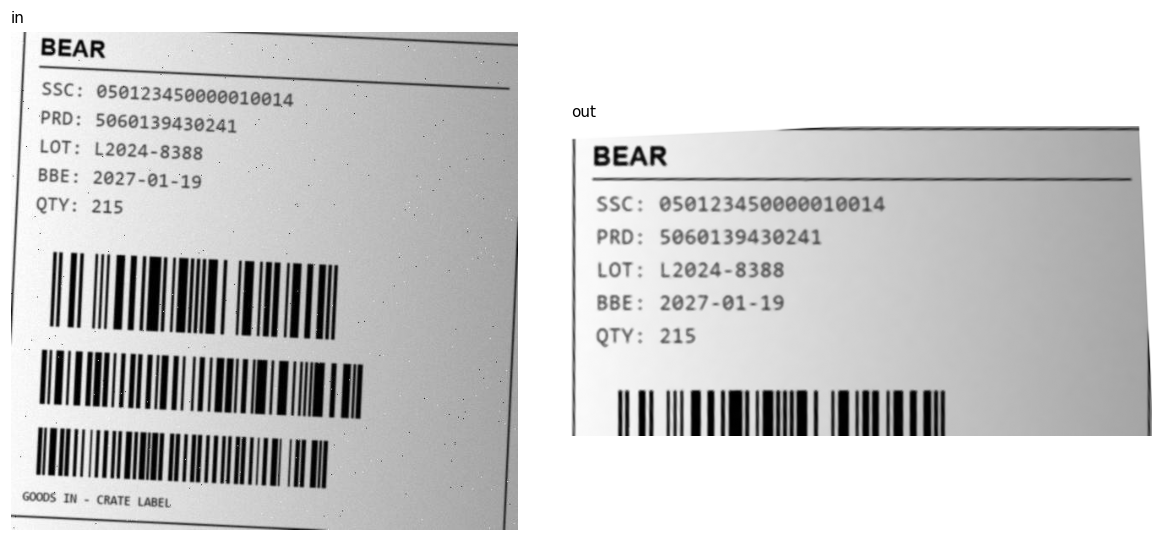

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 5))
ax[0].imshow(label, cmap="gray"); ax[0].set_title("in", fontsize=10, loc="left")
ax[1].imshow(cleaned, cmap="gray"); ax[1].set_title("out", fontsize=10, loc="left")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

Two things in there I got wrong and want to keep a note of.

**I tried to threshold the image myself.** Adaptive threshold plus a morphology open, which felt
like the obvious thing to do to text. It scored about 8 points *worse*. Tesseract binarises
internally and is better at it than my fixed block size was, so the denoised greyscale goes
straight through now.

**The denoiser's `searchWindowSize`.** The default is 21 and it costs about a second per ten
labels. I dropped it to 9 expecting to trade accuracy for speed and it got *faster and slightly
better*, because a big search window averages over half the label and softens the digits.

## the bug that cost me the most time

The deskew. Here it is:

In [8]:
show_code(deskew)

```python
def deskew(img):
    # straighten the label up. pyzbar kept missing the tilted ones before this
    inv = cv2.bitwise_not(img)
    _, th = cv2.threshold(inv, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    pts = cv2.findNonZero(th)
    if pts is None:
        return img

    angle = cv2.minAreaRect(pts)[-1]

    # my opencv returns angles in (-90, 0], so a label 1.3 degrees off arrives as -88.7.
    # i was bailing out on abs(angle) > 10 and that quietly switched the deskew off on
    # nearly every label. fold it into -45..45 first
    if angle > 45:
        angle = angle - 90
    elif angle < -45:
        angle = angle + 90

    if abs(angle) > 10:
        return img          # that will be the border, not the text

    h, w = img.shape
    m = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)

    # white corners, NOT replicate. replicate smears the black border into big wedges and
    # then tesseract returns nothing at all. took me ages, the picture still looks fine
    return cv2.warpAffine(img, m, (w, h), flags=cv2.INTER_CUBIC,
                          borderMode=cv2.BORDER_CONSTANT, borderValue=255)
```

Two separate bugs lived in those fifteen lines.

**`BORDER_REPLICATE`.** When you rotate an image you have to fill the corners with something, and
replicating the edge pixels sounds harmless. The label has a black border, so replicating smeared
it into huge black wedges. Tesseract returned `F M110` for the whole label. Eight of sixty came
back empty and the cleaned picture still looked completely fine to me, which is why it took so
long to find.

**The angle convention.** `minAreaRect` returns angles in `(-90, 0]` on my OpenCV, so a label
tilted 1.3 degrees comes back as **-88.7**. I had a guard saying "if it is more than 10 degrees
off, do not trust it" — which threw away almost every real measurement. Fixing that one line took
accuracy from 84.8% to 96.9%.

In [9]:
# what the raw number actually looks like, which is why the fold is needed
inv = cv2.bitwise_not(label)
_, th = cv2.threshold(inv, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
raw_angle = cv2.minAreaRect(cv2.findNonZero(th))[-1]
folded = raw_angle - 90 if raw_angle > 45 else (raw_angle + 90 if raw_angle < -45 else raw_angle)
print("minAreaRect says :", round(raw_angle, 2), "degrees")
print("actually means   :", round(folded, 2), "degrees")

minAreaRect says : -89.64 degrees
actually means   : 0.36 degrees


## third problem: tesseract gives you text, not fields

Even cleaned up, what comes back is messy. Tags get mangled, characters swap, whole lines vanish.
I started with regexes and they kept losing entire fields — read the `L` of `L2026-6851` as a `1`
and the pattern simply does not match, so the batch column came back empty on half the rows.

So it goes line by line instead:

In [10]:
show_code(reader.grab)

```python
def grab(tag, text):
    lines = text.splitlines()

    for line in lines:
        head, rest = split_head(line)
        if head == tag:
            return clean_val(rest)

    # tesseract mangles the tag itself too, QTY turns into OTY and LOT into 1OT. allow one
    # character out, but never steal a line that already belongs to another field
    for line in lines:
        head, rest = split_head(line)
        if not head or head in TAGS:
            continue
        best, dist = best_tag(head)
        if best == tag and dist <= 1:
            return clean_val(rest)

    for line in lines:
        i = line.upper().find(tag)
        if i != -1:
            return clean_val(line[i + len(tag):])

    # quantity is the only field with no barcode behind it, so it gets a last resort: a short
    # line of plain digits. one crate came back as just "77", another as "O:151".
    # the length cap is because the first version of this read the 13 digit product code as
    # the quantity and booked in a crate of three trillion boxes
    if tag == "QTY":
        for line in lines:
            s = line.strip()
            if s.isdigit() and len(s) <= 4:
                return s
        for line in lines:
            head, rest = split_head(line)
            if head and best_tag(head)[0] not in (None, "QTY"):
                continue
            val = rest.strip()
            if val.isdigit() and len(val) <= 4:
                return val
    return None
```

The bit at the bottom is my favourite bug in the project.

Quantity is the only field with no barcode behind it, so it gets a fallback: if the tag is
missing, take a line that is just digits. Then I added the thirteen digit product code, which is
a line of just digits with a colon in front of it. A crate of 85 boxes got booked in as
**3165433724019**.

In [11]:
print("code:", reader.grab("PRD", "PRD:3165433724019\nLOT:L2026-6851"))
print("qty :", reader.grab("QTY", "PRD:3165433724019\nLOT:L2026-6851"), "  <- refuses to guess now")
print()
print("tag mangled  :", reader.grab("QTY", "OTY 149"))
print("tag missing  :", reader.grab("QTY", "LOT:L2026-6851\n77"))

code: 3165433724019
qty : None   <- refuses to guess now

tag mangled  : 149
tag missing  : 77


## the barcodes, and why they matter more than the OCR

A barcode has a check digit. If a bar is smudged the checksum fails and zbar returns *nothing*
rather than something wrong. OCR has no such thing — it will hand you `HRD-AM-115` with total
confidence.

So where a barcode decodes, it wins, and the printed text becomes a cross check instead of the
source of truth.

In [12]:
show_code(reader.parse_gs1)

```python
def parse_gs1(payload):
    # 17YYMMDD then 10<batch digits>
    if not payload or not payload.isdigit() or len(payload) < 18:
        return "", ""
    if payload[:2] != "17" or payload[8:10] != "10":
        return "", ""
    bbe = "20%s-%s-%s" % (payload[2:4], payload[4:6], payload[6:8])
    digits = payload[10:]
    lot = "L%s-%s" % (digits[:4], digits[4:8])
    return lot, bbe
```

In [13]:
codes = reader.read_barcodes(label)
print("product  :", codes["ean"])
print("serial   :", codes["sscc"])
print("batch bc :", codes["gs1"], "->", reader.parse_gs1(codes["gs1"]))

product  : 5060139430241
serial   : 050123450000010014
batch bc : 172701191020248388 -> ('L2024-8388', '2027-01-19')


`17` is the best before as YYMMDD and `10` is the batch — those are GS1 application identifiers,
the same ones a real pallet label uses. `17` is fixed length so it goes first and `10` is variable
so it goes last, and then you do not need a separator between them.

## does any of it work? the numbers

Scored against the ground truth the generator wrote down. Two numbers: what the OCR manages on
its own, and what survives after the barcodes and the catalogue have repaired it.

In [14]:
FIELDS = ["sscc", "code", "lot_no", "bbe", "qty"]
truth = {r["filename"]: r for r in csv.DictReader(open("data/labels_truth.csv", encoding="utf-8"))}
rows = list(csv.DictReader(open("output/inventory.csv", newline="", encoding="utf-8")))


def score(rs):
    dist = chars = 0
    exact = {f: 0 for f in FIELDS}
    for r in rs:
        t = truth.get(r["filename"])
        if not t:
            continue
        for f in FIELDS:
            got = r.get(f, "") or ""
            dist += edit_distance(got, t[f]); chars += len(t[f])
            if got == t[f]:
                exact[f] += 1
    return 100 * (1 - dist / chars), exact


acc_raw, exact_raw = score(rows)

repaired, issued = [], []
for r in rows:
    fx, fl = check_crate(r, rules, "RUN-OAT-COOKIE", issued)
    repaired.append(fx)
    if outcome(fl) != "REJECTED":
        issued.append({"sscc": fx.get("sscc", ""), "code": fx.get("code", ""),
                       "allergens": fx.get("allergens", "")})
acc_fix, exact_fix = score(repaired)

print("off the ocr    : %.1f%%" % acc_raw)
print("after repairs  : %.1f%%" % acc_fix)
print()
print("%-10s %12s %14s" % ("", "off the ocr", "after repairs"))
for f in FIELDS:
    print("%-10s %10d/60 %12d/60" % (f, exact_raw[f], exact_fix[f]))

off the ocr    : 95.5%
after repairs  : 99.6%

            off the ocr  after repairs
sscc               44/60           59/60
code               57/60           60/60
lot_no             53/60           60/60
bbe                53/60           60/60
qty                54/60           54/60


**This table is the thing I would point at if somebody asked me one question about the project.**

The crate serial is the worst field off the OCR — it is eighteen digits, and every extra digit is
another chance to misread one. After the barcode repairs it is nearly perfect.

The case count is the only row that does not improve. It is also the only field with no barcode
behind it. That is not a coincidence, it is the entire design: where a checksum-backed code
exists the reading becomes reliable no matter how bad the print is, and where it does not, the
OCR is on its own and you can measure exactly what that costs.

It is also the answer to "why bother with OCR if you have barcodes" — because the printed text is
what catches a crate wearing the wrong label, and because not everything is in a barcode.

In [15]:
# and what the opencv step is worth. a dozen labels, it is slow
sample = sorted(glob.glob("data/labels/*.png"))[:12]
with_pre = score([reader.read_label(p, use_preprocess=True) for p in sample])[0]
without = score([reader.read_label(p, use_preprocess=False) for p in sample])[0]
print("with preprocessing    : %.1f%%" % with_pre)
print("without it            : %.1f%%" % without)
print("difference            : %.1f points" % (with_pre - without))

with preprocessing    : 99.1%
without it            : 40.5%
difference            : 58.6 points


## fourth problem: a reading is not a decision

This is the part I think is actually the project. Having read the crate, what do you do with it?

My first version was pass or fail, and it was wrong. A crate the reader could not make out and a
crate of pistachios that genuinely must not go near an oat cookie line are *different problems for
different people*. So there are three outcomes:

In [16]:
show_code(outcome)

```python
def outcome(flags):
    if any(base(f) in UNSURE for f in flags):
        return "HELD"
    if any(base(f) in NONCONFORMING for f in flags):
        return "REJECTED"
    return "ACCEPTED"
```

The rule underneath that is the one I would defend in an interview:

> **you cannot reject a crate on a reading you do not trust.**

If the barcode will not scan and the product code then looks unknown, the honest answer is not
"rejected, unknown product". It is "I could not read this, somebody come and look" — because the
unknown code might just be the misreading talking. So anything uncertain is HELD even when it
*also* looks non-conforming.

In [17]:
for flags in [[],
              ["BARCODE_UNREADABLE"],
              ["UNDECLARED_ALLERGEN:nuts"],
              ["BARCODE_UNREADABLE", "CODE_NOT_IN_CATALOGUE"]]:
    print("%-9s <- %s" % (outcome(flags), flags or "no flags"))

ACCEPTED  <- no flags
HELD      <- ['BARCODE_UNREADABLE']
REJECTED  <- ['UNDECLARED_ALLERGEN:nuts']
HELD      <- ['BARCODE_UNREADABLE', 'CODE_NOT_IN_CATALOGUE']


That last line is the interesting one. It looks like an unknown product *and* an unreadable
barcode, and it comes out HELD rather than REJECTED, because the second flag is the reason not to
trust the first.

## the whole delivery

Sixty crates arriving for `RUN-OAT-COOKIE`, an oat cookie whose packet declares
"contains gluten, milk". That declaration is what everything gets checked against.

In [18]:
tally = {"ACCEPTED": 0, "HELD": 0, "REJECTED": 0}
by_type, refused, issued = {}, [], []

for r in rows:
    fx, fl = check_crate(r, rules, "RUN-OAT-COOKIE", issued)
    st = outcome(fl)
    tally[st] += 1
    cat = fx.get("category") or "not in the catalogue"
    by_type.setdefault(cat, {"ACCEPTED": 0, "HELD": 0, "REJECTED": 0})[st] += 1
    if st != "REJECTED":
        issued.append({"sscc": fx.get("sscc", ""), "code": fx.get("code", ""),
                       "allergens": fx.get("allergens", "")})
    else:
        refused.append(((fx.get("product_name") or "(not in the catalogue)")[:34], ";".join(fl)))

total = sum(tally.values())
for k in ["ACCEPTED", "HELD", "REJECTED"]:
    print("%-9s %2d" % (k, tally[k]))
print("\nso %d of %d needed a person, manual checking down %.0f%%"
      % (total - tally["ACCEPTED"], total, 100.0 * tally["ACCEPTED"] / total))

ACCEPTED  48
HELD       7
REJECTED   5

so 12 of 60 needed a person, manual checking down 80%


In [19]:
print("%-22s %6s %9s %6s %9s" % ("", "crates", "accepted", "held", "rejected"))
for cat in sorted(by_type):
    t = by_type[cat]
    print("%-22s %6d %9d %6s %9s" % (cat.replace("-", " "), sum(t.values()),
                                     t["ACCEPTED"], t["HELD"] or "", t["REJECTED"] or ""))

                       crates  accepted   held  rejected
breakfast cereals           5         3      2          
chocolates                  4         2      1         1
dried fruits               15        12      2         1
flours                      6         6                 
not in the catalogue        1         0                1
nuts                        1         0                1
sugars                     12        12                 
vegetable oils             16        13      2         1


In [20]:
for name, why in refused:
    print("%-36s %s" % (name, why))

Soft apricots                        UNDECLARED_ALLERGEN:sulphites
(not in the catalogue)               CODE_NOT_IN_CATALOGUE
Black Forest cherry dark chocolate   UNDECLARED_ALLERGEN:soybeans
Olive Oil                            EXPIRED
Roasted Pistachios                   NOT_ON_RUN_SPEC:nuts;UNDECLARED_ALLERGEN:nuts


**Roasted pistachios is the one to look at.** There is nothing wrong with that crate. It is a
perfectly good bag of nuts, in date, from a real supplier, correctly labelled. It is going into a
product whose packet does not say "contains nuts", and that is a recall.

Nobody reading that label carefully would catch it, because the problem is not on the label. It
is the combination of this crate and this run.

## then i pointed a camera at it

The desk version has somebody holding each crate up. A camera over a conveyor does not, and it
broke in a way I did not expect: **finding the label turned out to be harder than reading it.**

A label photographed from an angle is not rotated, it is a trapezoid — the far edge really is
shorter, and no amount of turning fixes that. So `deperspective()` finds the four corners and
warps them back to a rectangle, same as a scanner app does to a photo of a page.

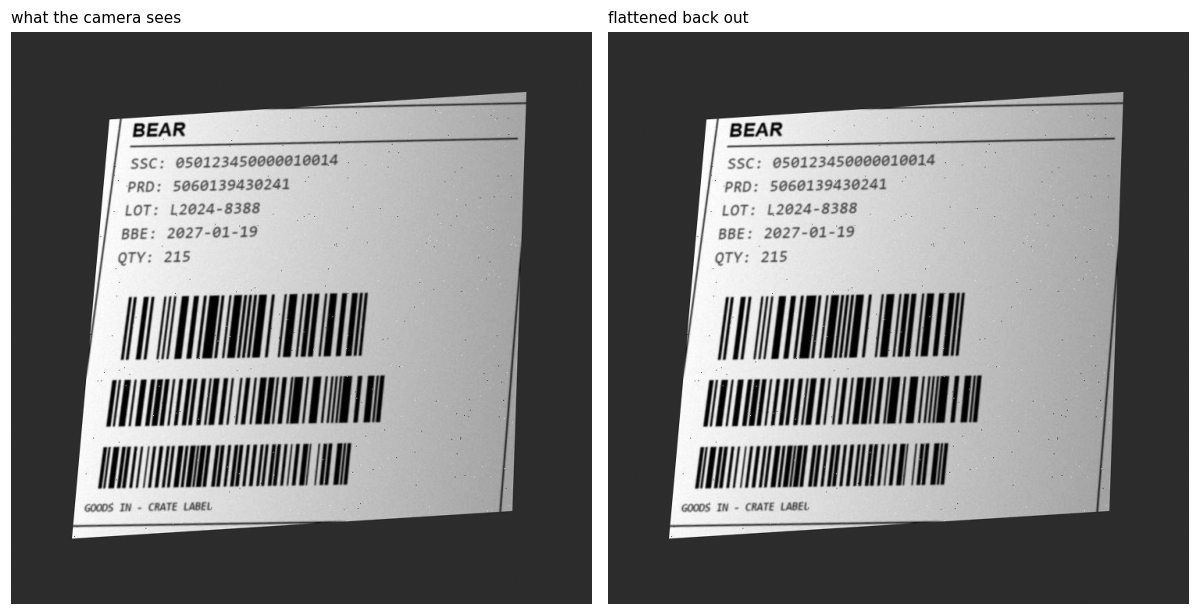

In [21]:
def tilt(img, strength=0.10):
    h, w = img.shape
    pad = int(max(h, w) * 0.12)
    canvas = np.full((h + 2 * pad, w + 2 * pad), 45, np.uint8)
    canvas[pad:pad + h, pad:pad + w] = img
    src = np.array([[pad, pad], [pad + w, pad], [pad + w, pad + h], [pad, pad + h]], np.float32)
    dx, dy = w * strength, h * strength
    dst = np.array([[pad + dx * .9, pad + dy * .7], [pad + w - dx * .2, pad + dy * .1],
                    [pad + w - dx * .5, pad + h - dy * .8], [pad + dx * .1, pad + h - dy * .2]],
                   np.float32)
    m = cv2.getPerspectiveTransform(src, dst)
    return cv2.warpPerspective(canvas, m, (w + 2 * pad, h + 2 * pad), flags=cv2.INTER_CUBIC,
                               borderMode=cv2.BORDER_CONSTANT, borderValue=45)


angled = tilt(label)
flat = deperspective(angled)

fig, ax = plt.subplots(1, 2, figsize=(11, 6))
ax[0].imshow(angled, cmap="gray"); ax[0].set_title("what the camera sees", fontsize=10, loc="left")
ax[1].imshow(flat, cmap="gray"); ax[1].set_title("flattened back out", fontsize=10, loc="left")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

Over 25 labels: **99.1%** square on, **82.9%** tilted, **98.0%** tilted and then flattened.
`python angle_test.py` runs that.

Three more things I got wrong while doing the camera version, all of them about *finding* the
label rather than reading it:

- **I anchored the crop on the barcodes**, since they had just decoded and pyzbar tells you where
  it found them. But pyzbar reports where the *bars* are, and a barcode image is bars plus a 3mm
  quiet zone — 24px at 200dpi. So the crop started inside the label and sliced the left edge off
  every field tag.
- **I drew the conveyor mid grey.** Too close in tone to a white label to segment apart, and
  tesseract read the tread lines as characters and stapled them onto the end of whatever field
  shared that row: `L2024-0452YEV`, `78PN`. Real belts are black rubber, which is both more
  realistic and the easy case.
- **I resized to the label size whether or not the flattening had worked.** The corner finder
  gives up sometimes and hands the picture back untouched, and I squashed those into a
  label-shaped box anyway. Flattening scored *worse than doing nothing* until I checked.

## and on photographs i did not make

Everything above is measured on labels I generated, which is a fair thing to be suspicious of. So
I ran the same reader over photos other people took of real products, off Open Food Facts. Bad
light, glare, packaging bent round a jar.

```
photos looked at:         70
barcode decoded in:        9
  and it was correct:      9
  and it was wrong:        0
brand name read off photo: 11 of 67
```

**The zero is the number that matters** on the barcode side. Nine decodes, nine right, nothing
invented. The low count is because most of those photos are front-of-pack shots with no barcode in
frame at all.

**The 11 of 67 is the honest one.** This is built for flat printed labels in a known layout and it
is not much good at a curved jar in somebody's kitchen. Worth knowing, and worth writing down
rather than only ever testing on pictures I drew myself. `python real_photo_test.py` re-runs it.

## what it does not do

It never looks at the goods. It reads a label and checks it against master data. It cannot tell
you the flour is damp or the oil has gone off — only that this crate is, or is not, the thing this
run is allowed to use.

The crates are synthetic, so the accuracy figure is accuracy on my generator, not a promise about
a photo of a real pallet. Glare off shrink wrap, dust and creased labels are not simulated.

The layout is fixed. Point it at a different supplier's label and the barcodes still decode but
the printed fields come back empty — supporting a new format means adding its layout, though the
checking logic would not change.

Open Food Facts is crowd sourced, so the catalogue has real mess in it. The absence of an allergen
tag is not proof there is no allergen, which in a real plant would matter a great deal.

**If I kept going**, the next thing would be tesseract's own confidence scores. Right now
HELD versus ACCEPTED is decided by format rules, and the reader never gets to say how sure it is,
which seems like leaving information on the table.